In [31]:
import numpy as np
import pandas as pd
import polars as pl
from sklearn.impute import SimpleImputer
from sklearn.model_selection import TimeSeriesSplit
from lightgbm import LGBMRegressor
import kaggle_evaluation.default_inference_server
import os

## Data Loading

In [32]:
train_set = pd.read_csv('/kaggle/input/hull-tactical-market-prediction/train.csv')

# Create lagged features BEFORE splitting (they're already lagged, no leakage)
train_set['lagged_forward_returns'] = train_set['forward_returns'].shift(1)
train_set['lagged_risk_free_rate'] = train_set['risk_free_rate'].shift(1)
train_set['lagged_market_forward_excess_returns'] = train_set['market_forward_excess_returns'].shift(1)

# Split: use more data for training, smaller holdout for final check
train_data = train_set[1005:-180]
test_data = train_set[-180:]



## Feature Engineering

In [33]:
def create_features(df):
    """Add engineered features - called on full dataset to avoid leakage"""
    df = df.copy()
    
    # Volatility proxy
    df['returns_squared'] = df['lagged_forward_returns'] ** 2
    
    # Momentum: recent cumulative returns
    df['momentum_5'] = df['lagged_forward_returns'].rolling(5).sum()
    df['momentum_20'] = df['lagged_forward_returns'].rolling(20).sum()
    
    # Volatility: recent standard deviation
    df['volatility_5'] = df['lagged_forward_returns'].rolling(5).std()
    df['volatility_20'] = df['lagged_forward_returns'].rolling(20).std()
    
    # Interaction: return vs risk-free rate spread
    df['excess_return'] = df['lagged_forward_returns'] - df['lagged_risk_free_rate']
    
    return df

# Apply feature engineering to full training set
train_set = create_features(train_set)
train_data = train_set[1005:-180]
test_data = train_set[-180:]

In [34]:
base_features = [col for col in train_data.columns 
                 if col not in ['date_id', 'forward_returns', 'risk_free_rate', 
                               'market_forward_excess_returns']]


## Preprocessing

In [35]:
X_train = train_data[base_features].values
y_train = train_data['forward_returns'].values
X_test = test_data[base_features].values
y_test = test_data['forward_returns'].values

# Impute missing values
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)


## Allocation and Sharpe

In [36]:
def convert_to_allocations(predictions):
    scaled = []
    for i in range(len(predictions)):
        if i > 0:
            if predictions[i] > predictions[i-1] and predictions[i] > 0 :
               scaled.append(1.6 + predictions[i] * 30)
            elif predictions[i] < predictions[i-1] and predictions[i] > 0:
                scaled.append(1.2 + predictions[i] * 10)
            elif predictions[i] > predictions[i-1] and predictions[i] < 0:
                scaled.append(0.5 + predictions[i] * 20)
            elif predictions[i] < predictions[i-1] and predictions[i] < 0:
                scaled.append(0 + predictions[i] * 10)
        else:
            if predictions[i] > 0:
                scaled.append(1.5 + predictions[i] * 30)
            else:
                scaled.append(0.0 + predictions[i] * 10)
        
    # scaled = np.where(predictions > 0, 
    #                  1.5 + predictions * 30, 
    #                  0.01 + predictions * 10)
    return np.clip(scaled, 0.0, 2.0)
#     # Scale predictions: roughly 1.0 baseline, move to 0-2 based on prediction
#     # allocations = 1.0 + (predictions * 30)
#     # return np.clip(allocations, 0.0, 2.0)


In [37]:
def convert_to_allocations(predictions):
    """
    Trend-following allocation strategy.
    More aggressive when prediction increases, more defensive when decreasing.
    """
    scaled = []
    for i in range(len(predictions)):
        pred = predictions[i]
        
        if i > 0:
            trend_up = predictions[i] > predictions[i-1]
            
            if pred > 0:
                # Positive prediction
                if trend_up:
                    scaled.append(1.6 + pred * 30)  # Aggressive
                else:
                    scaled.append(1.2 + pred * 10)  # Conservative
            else:
                # Negative prediction
                if trend_up:
                    scaled.append(0.5 + pred * 20)  # Slightly bullish despite negative
                else:
                    scaled.append(0.0 + pred * 10)  # Very defensive
        else:
            # First prediction - no trend available
            if pred > 0:
                scaled.append(1.5 + pred * 30)
            else:
                scaled.append(0.0 + pred * 10)
    
    return np.clip(scaled, 0.0, 2.0)

In [38]:

def sharpe_ratio(returns, allocations, risk_free_rates):
    """
    Calculate adjusted Sharpe ratio matching competition metric.
    Includes volatility and return penalties.
    """
    # Calculate strategy returns (blend of risk-free rate and market returns based on allocation)
    strategy_returns = risk_free_rates * (1 - allocations) + allocations * returns
    
    # Strategy's Sharpe ratio
    strategy_excess_returns = strategy_returns - risk_free_rates
    strategy_excess_cumulative = (1 + strategy_excess_returns).prod()
    strategy_mean_excess_return = (strategy_excess_cumulative) ** (1 / len(returns)) - 1
    strategy_std = strategy_returns.std()
    
    trading_days_per_yr = 252
    if strategy_std == 0:
        return 0.0
    
    sharpe = strategy_mean_excess_return / strategy_std * np.sqrt(trading_days_per_yr)
    strategy_volatility = strategy_std * np.sqrt(trading_days_per_yr) * 100
    
    # Market return and volatility
    market_excess_returns = returns - risk_free_rates
    market_excess_cumulative = (1 + market_excess_returns).prod()
    market_mean_excess_return = (market_excess_cumulative) ** (1 / len(returns)) - 1
    market_std = returns.std()
    market_volatility = market_std * np.sqrt(trading_days_per_yr) * 100
    
    if market_volatility == 0:
        return 0.0
    
    # Volatility penalty (penalize if strategy volatility > 1.2x market volatility)
    excess_vol = max(0, strategy_volatility / market_volatility - 1.2)
    vol_penalty = 1 + excess_vol
    
    # Return penalty (penalize if strategy underperforms market)
    return_gap = max(0, (market_mean_excess_return - strategy_mean_excess_return) * 100 * trading_days_per_yr)
    return_penalty = 1 + (return_gap**2) / 100
    
    # Adjusted Sharpe ratio
    adjusted_sharpe = sharpe / (vol_penalty * return_penalty)
    return min(adjusted_sharpe, 1_000_000)


## Cross Validation

In [39]:

tscv = TimeSeriesSplit(n_splits=5)
cv_sharpes = []
cv_r2s = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    
    # Train model
    cv_model = LGBMRegressor(
        objective='regression',
        boosting_type='gbdt',
        learning_rate=0.05,
        num_leaves=31,
        max_depth=6,
        n_estimators=500,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=5,
        random_state=42,
        verbose=-1
    )
    cv_model.fit(X_tr, y_tr)
    
    # Predict
    predictions = cv_model.predict(X_val)
    
    # R² score
    ss_res = np.sum((y_val - predictions) ** 2)
    ss_tot = np.sum((y_val - y_val.mean()) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    
    # Sharpe ratio (need risk-free rates for adjusted calculation)
    allocations = convert_to_allocations(predictions)
    risk_free_rates = train_data.iloc[val_idx]['risk_free_rate'].values
    sharpe = sharpe_ratio(y_val, allocations, risk_free_rates)
    
    cv_r2s.append(r2)
    cv_sharpes.append(sharpe)

## Final Model Training

In [40]:
model = LGBMRegressor(
    objective='regression',
    boosting_type='gbdt',
    learning_rate=0.05,
    num_leaves=31,
    max_depth=6,
    n_estimators=500,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    random_state=42,
    verbose=-1
)

model.fit(X_train, y_train)

LGBMRegressor(bagging_fraction=0.8, bagging_freq=5, feature_fraction=0.8,
              learning_rate=0.05, max_depth=6, n_estimators=500,
              objective='regression', random_state=42, verbose=-1)

In [41]:
predictions = model.predict(X_test)
allocations = convert_to_allocations(predictions)
risk_free_rates_test = test_data['lagged_risk_free_rate'].values
holdout_sharpe = sharpe_ratio(y_test, allocations, risk_free_rates_test)

print(f"\nHoldout Sharpe Ratio: {holdout_sharpe:.5f}")
print(f"Mean prediction error: {np.mean(y_test - predictions):.4f}")
print(f"Mean absolute error: {np.mean(np.abs(y_test - predictions)):.4f}")


Holdout Sharpe Ratio: 0.48583
Mean prediction error: -0.0010
Mean absolute error: 0.0081


In [42]:
allocations = convert_to_allocations(y_test)
risk_free_rates_test = test_data['lagged_risk_free_rate'].values
holdout_sharpe = sharpe_ratio(y_test, allocations, risk_free_rates_test)
print(f"\nHoldout Sharpe Ratio: {holdout_sharpe:.5f}")
print(f"Mean prediction error: {np.mean(y_test - predictions):.4f}")
print(f"Mean absolute error: {np.mean(np.abs(y_test - predictions)):.4f}")


Holdout Sharpe Ratio: 9.21699
Mean prediction error: -0.0010
Mean absolute error: 0.0081


In [43]:
print(allocations.round(2))
allocations.shape

[1.68 1.93 1.2  0.   0.   0.43 0.45 1.98 1.26 0.   1.64 0.   1.65 1.21
 2.   0.   1.9  1.29 1.26 1.25 0.   0.   1.86 0.   1.76 0.   0.   1.8
 1.24 1.23 0.   1.8  1.21 0.   1.92 0.   1.69 1.22 0.   0.   0.41 0.
 1.62 0.   2.   0.   0.26 1.92 0.   1.77 0.   0.33 1.76 0.   2.   1.28
 0.   1.93 0.   1.61 2.   1.22 0.   0.45 0.   1.8  1.23 1.79 0.   0.
 0.46 0.   2.   0.   2.   1.3  0.   0.   1.64 0.   2.   1.35 2.   1.27
 1.2  1.79 1.2  1.81 2.   0.   0.   1.73 1.81 0.   2.   1.27 1.21 1.75
 1.79 1.21 0.   0.   1.61 0.   2.   0.   1.72 0.   1.77 1.77 0.   0.
 1.91 1.21 1.77 0.   1.72 0.   1.89 0.   0.5  0.   1.9  1.93 1.21 1.83
 1.25 1.25 0.   1.74 1.84 0.   0.49 1.78 1.23 0.   1.66 0.   1.7  1.78
 0.   1.66 1.2  1.86 1.2  1.73 0.   0.   0.47 0.   0.   2.   0.   1.83
 0.   1.83 0.   1.92 1.23 1.2  0.   0.5  0.   0.45 0.   2.   0.   1.73
 1.22 1.71 0.   0.   1.76 1.85 0.   1.67 1.22 1.69 1.85 1.2 ]


(180,)

In [44]:
print(predictions.round(4))

[-0.0038  0.0003 -0.     -0.0002 -0.0016 -0.0029 -0.0015 -0.0016 -0.0005
 -0.0008 -0.0002 -0.0015 -0.0034 -0.0026 -0.0011 -0.0016  0.0008  0.0003
  0.      0.0006 -0.0004 -0.001   0.0004 -0.0014  0.0008  0.0019  0.0019
  0.002   0.0027  0.0019  0.0012  0.0023  0.0012  0.0019  0.0015  0.0027
  0.0021  0.001   0.001   0.0022  0.001   0.0024  0.0058  0.004   0.0093
  0.0007  0.0047  0.0013  0.0045  0.0046  0.0085  0.005   0.0109  0.0056
  0.0065  0.002   0.0092  0.0068  0.0085  0.0062  0.0033 -0.0007  0.0027
  0.0026  0.0029  0.0069 -0.0018  0.0039  0.006   0.008   0.0321  0.011
  0.0131 -0.0071  0.0043  0.0031  0.0033  0.0029  0.0075  0.0095  0.0088
  0.0081  0.0042  0.002   0.0035 -0.0004  0.0018  0.0021  0.002   0.0043
  0.003   0.0017 -0.0008  0.0042  0.0038  0.0001  0.0001  0.0008  0.0017
 -0.0062 -0.0044  0.002   0.0011  0.0008  0.004  -0.0018  0.0014  0.0012
 -0.0008  0.0009 -0.      0.002   0.0028  0.0012 -0.0002  0.0009  0.002
  0.0003 -0.0004 -0.001   0.0018  0.0017  0.0026  0.0

In [45]:
print(y_test.round(4))

[ 0.006   0.0111  0.0001 -0.0105 -0.0114 -0.0036 -0.0025  0.0125  0.0058
 -0.0113  0.0015 -0.0153  0.0016  0.0014  0.0182 -0.0019  0.01    0.0092
  0.0056  0.0055 -0.0029 -0.0141  0.0086 -0.0045  0.0054 -0.0053 -0.0067
  0.0067  0.0041  0.0035 -0.0092  0.0068  0.0008 -0.0032  0.0106 -0.
  0.0029  0.0024 -0.0042 -0.0171 -0.0046 -0.005   0.0005 -0.016   0.0156
 -0.0175 -0.0118  0.0107 -0.0178  0.0056 -0.0266 -0.0083  0.0053 -0.0133
  0.0207  0.0077 -0.0108  0.0109 -0.0029  0.0003  0.0179  0.0024 -0.0119
 -0.0027 -0.0201  0.0067  0.0028  0.0063 -0.0396 -0.0396 -0.0018 -0.0157
  0.0407 -0.0398  0.0178  0.0097 -0.0028 -0.0222  0.0014 -0.0238  0.026
  0.0155  0.021   0.0072  0.0004  0.0063  0.0004  0.0071  0.0148 -0.0057
 -0.0084  0.0042  0.007  -0.0013  0.033   0.0066  0.0013  0.0049  0.0063
  0.0011 -0.0034 -0.0169  0.0004 -0.0068  0.0208 -0.0058  0.0039 -0.0011
  0.0056  0.0057 -0.0003 -0.0048  0.0103  0.0009  0.0057 -0.0029  0.004
 -0.0112  0.0095 -0.0085 -0.0002 -0.0023  0.0099  0.011  

## Inference

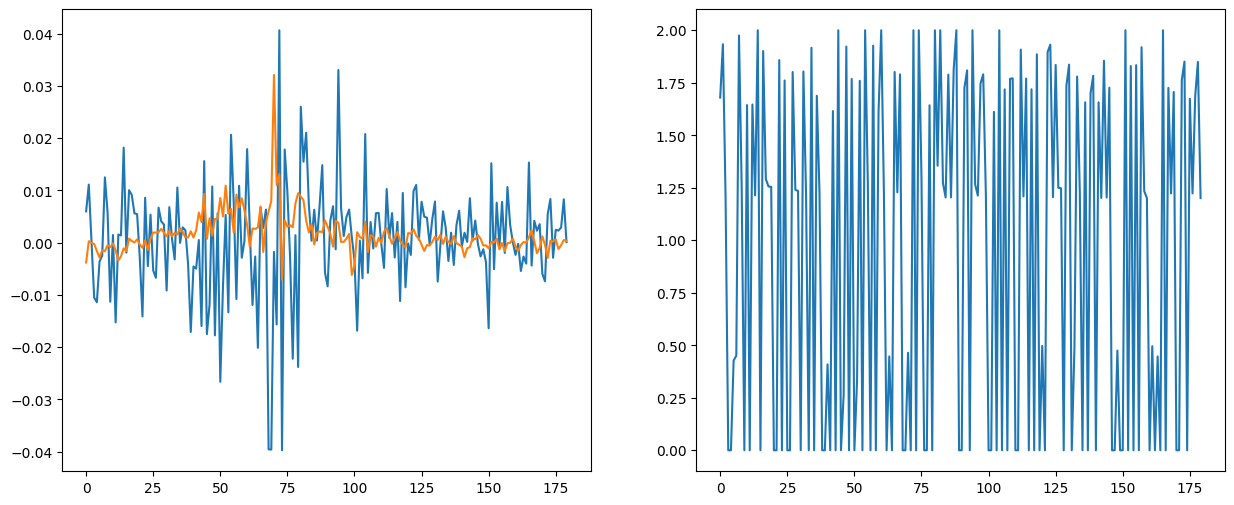

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.subplot(1,2,1)
plt.plot(y_test)
plt.plot(predictions)
plt.subplot(1,2,2)
plt.plot(allocations)


plt.show()

In [47]:

def predict(test: pl.DataFrame):
    """Prediction function for Kaggle API"""
    test_pd = test.to_pandas()
    
    # Create same features as training
    test_pd = create_features(test_pd)
    
    # Extract features
    test_features = test_pd[base_features].values
    test_features = imputer.transform(test_features)
    
    # Predict
    raw_pred = model.predict(test_features)[0]
    allocation = convert_to_allocations(np.array([raw_pred]))[0]
    
    return float(allocation)

# ============================================================================
# INFERENCE SERVER
# ============================================================================
inference_server = kaggle_evaluation.default_inference_server.DefaultInferenceServer(predict)

if os.getenv('KAGGLE_IS_COMPETITION_RERUN'):
    inference_server.serve()
else:
    inference_server.run_local_gateway(('/kaggle/input/hull-tactical-market-prediction/',))